# Comparing bulk and diss bulk refs for genetic demultiplexing

Compare the assignments between the two refs as a sanity check on the results.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from typing import Literal

In [2]:
cwd = os.getcwd()

In [3]:
n_pool = 10  # number of pools

## Load data

In [4]:
def load_all_gex_data(ref: Literal["bulk", "diss_bulk"]):
    
    df = pd.DataFrame()
    
    for pool in range(1, n_pool + 1):
        
        gex_file = cwd + f"/vireo_{ref}/pool{pool}/donor_ids.tsv"
        gex_df = pd.read_csv(gex_file, delimiter="\t")
        gex_df["pool"] = pool
        
        df = pd.concat([df, gex_df])
        
    df.reset_index(drop=True, inplace=True)
    
    return df

In [5]:
bulk_df = load_all_gex_data("bulk")
diss_df = load_all_gex_data("diss_bulk")

In [6]:
bulk_df.head()

,cell,donor_id,prob_max,prob_doublet,n_vars,best_singlet,best_doublet,doublet_logLikRatio,pool
0,AAACCCAAGAACCCGA-1,230509/2094,1.0,1.130000e-133,2198,230509/2094,"230509/2018,230509/2094",-303.172,1
1,AAACCCAAGCCTATCA-1,230509/2126,1.0,2.840000e-08,1359,230509/2126,"230509/2023,230509/2094",-14.428,1
2,AAACCCAAGCTGAGCA-1,230509/2126,1.0,9.540000e-236,1825,230509/2126,"230509/2023,230509/2094",-538.205,1
3,AAACCCACAAGAGTTA-1,230509/2018,1.0,3.920000e-40,1731,230509/2018,"230509/2018,230509/2023",-87.787,1
4,AAACCCAGTCATCGGC-1,230509/2126,1.0,7.370000e-113,2181,230509/2126,"230509/2023,230509/2094",-255.245,1


In [7]:
len(bulk_df), len(diss_df)

(81074, 81074)

In [10]:
sample_id_mapping = pd.read_excel(cwd + "/samples_overview.xlsx", sheet_name="Sheet2")

In [11]:
sample_id_mapping.head()

,Bulk sample id,Diss bulk sample id,Pool #,Notes
0,2018,2018,1,NaN
1,2023,2023,1,NaN
2,2094,2094,1,NaN
3,2126,2126,1,NaN
4,2129,2129,2,NaN


# Cell assignments histogram

In [25]:
def plot_assigned_cells_per_pool_hist(ref: Literal["bulk", "diss_bulk"], sample_id_mapping: pd.DataFrame, save: bool = False):
    
    if ref == "bulk":
        df = bulk_df
    elif ref == "diss_bulk":
        df = diss_df
        
    df = df.replace({r"\d{6}/": ""}, regex=True)

    fig, ax = plt.subplots(2, 5, figsize=(15, 5), sharey=True)

    for i in range(1, n_pool + 1):
        sample_id_mapping_pool1 = sample_id_mapping[sample_id_mapping["Pool #"]==i]
        sample_id_map = sample_id_mapping_pool1[["Bulk sample id", "Diss bulk sample id"]].set_index("Bulk sample id").to_dict()["Diss bulk sample id"]
        sample_id_map = {k: str(v) for k, v in sample_id_map.items()}
        
        hist_data = df.loc[df["pool"]==i, "donor_id"].value_counts()
        hist_data.rename(index=sample_id_map, inplace=True)
        hist_order = sorted(hist_data.index)
        hist_data = hist_data[hist_order]
        
        index_y = (i-1)%5
        index_x = (i-1)//5
        
        ax[index_x, index_y].bar(hist_data.index, hist_data)
        ax[index_x, index_y].set_title(f"Pool {i}")
        ax[index_x, index_y].spines[['right', 'top']].set_visible(False)
        ax[index_x, index_y].set_xticks(range(len(hist_data)))
        ax[index_x, index_y].set_xticklabels(hist_data.index, rotation=30, ha="center")
        ax[index_x, index_y].text(0.8, 0.8, f"{hist_data.sum()}", ha="center", va="center", transform=ax[index_x, index_y].transAxes)
        
    ax[0, 0].set_ylabel("Assigned cells")
    ax[1, 0].set_ylabel("Assigned cells")
    ax[0, 0].text(0.8, 0.9, "Total # cells:", ha="center", va="center", transform=ax[0, 0].transAxes)

    fig.subplots_adjust(hspace=0.6)
    plt.show()
    
    if save:
        figname = f"plots/gex_dmx_{ref}_assigned_cells"
        fig.savefig(figname + ".pdf", bbox_inches="tight")
        fig.savefig(figname + ".png", bbox_inches="tight", dpi=150)


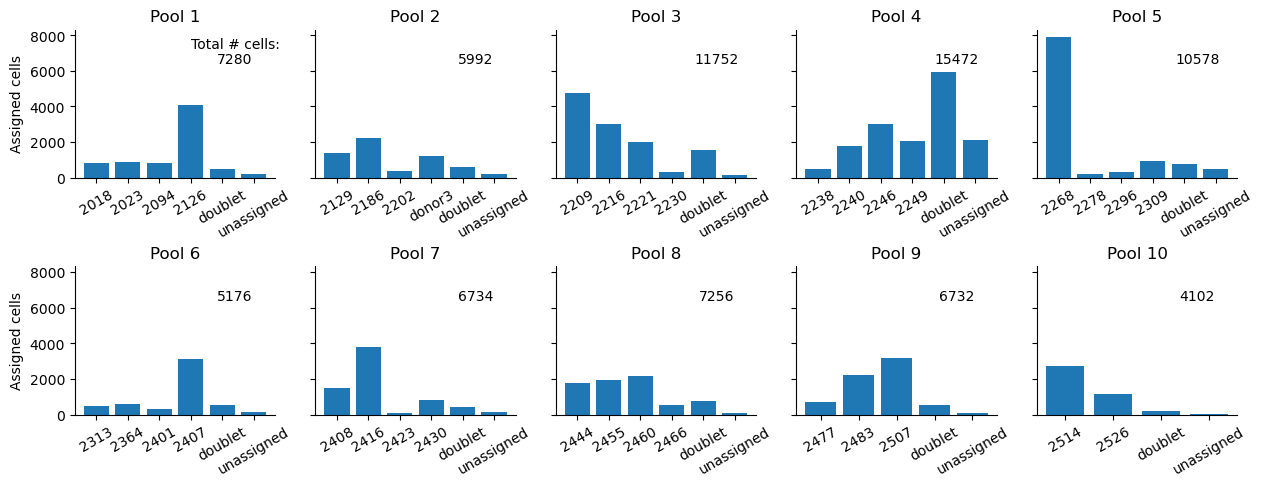

In [26]:
plot_assigned_cells_per_pool_hist("bulk", sample_id_mapping)

In [27]:
# Check which samples have less than 500 cells assigned to them
for i in range(1, n_pool + 1):
    tally = bulk_df.loc[bulk_df["pool"]==i, "donor_id"].value_counts()
    tally.drop(["doublet", "unassigned"], inplace=True)
    
    if not tally[tally < 500].empty:
        print(f"pool {i}")
        print(tally[tally < 500])

pool 2
230509/2202    388
Name: donor_id, dtype: int64
pool 3
230626/2230    328
Name: donor_id, dtype: int64
pool 4
230626/2238    478
Name: donor_id, dtype: int64
pool 5
230626/2296    300
230626/2278    200
Name: donor_id, dtype: int64
pool 6
230509/2313    452
230509/2401    331
Name: donor_id, dtype: int64
pool 7
230626/2423    91
Name: donor_id, dtype: int64


# Cell assignment heatmaps

In [28]:
bulk_sub_df = bulk_df[["cell", "donor_id", "pool"]]
diss_bulk_sub_df = diss_df[["cell", "donor_id", "pool"]]

In [29]:
df = pd.merge(
    bulk_sub_df, 
    diss_bulk_sub_df, 
    how="outer", 
    on=["cell", "pool"], 
    suffixes=["_bulk", "_diss"]
)

In [30]:
df.head()

,cell,donor_id_bulk,pool,donor_id_diss
0,AAACCCAAGAACCCGA-1,230509/2094,1,230418/2094
1,AAACCCAAGCCTATCA-1,230509/2126,1,230414/2126
2,AAACCCAAGCTGAGCA-1,230509/2126,1,230414/2126
3,AAACCCACAAGAGTTA-1,230509/2018,1,230414/2018
4,AAACCCAGTCATCGGC-1,230509/2126,1,230414/2126


In [31]:
def pivot_gex_data(df, pool):
    
    sub_df = df[df["pool"]==pool]
    
    assignments_df = pd.DataFrame(sub_df[["donor_id_bulk", "donor_id_diss"]].value_counts())
    assignments_df.columns = ["count"]
    assignments_df = assignments_df.reset_index(drop=False)
    
    pivot_df = assignments_df.pivot(columns="donor_id_bulk", index="donor_id_diss", values="count")
    
    return pivot_df

In [32]:
pivot_gex_data(df, 1)

donor_id_bulk,230509/2018,230509/2023,230509/2094,230509/2126,doublet,unassigned
donor_id_diss,,,,,,
230414/2018,824.0,NaN,NaN,NaN,8.0,4.0
230414/2023,NaN,822.0,NaN,NaN,NaN,2.0
230414/2126,NaN,NaN,NaN,4032.0,37.0,46.0
230418/2094,NaN,NaN,782.0,NaN,NaN,4.0
doublet,11.0,24.0,24.0,16.0,369.0,31.0
unassigned,4.0,11.0,10.0,30.0,86.0,103.0


In [33]:
def viz_gex_heatmap_diss_vs_bulk(df, pool: int, save: bool = False):
    
    pivot_df = pivot_gex_data(df, pool)
    
    fig, ax = plt.subplots()
    ax.matshow(pivot_df, cmap='Oranges')

    for (i, j), z in np.ndenumerate(pivot_df):
        ax.text(j, i, '{:.0f}'.format(z), ha='center', va='center')

    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_yticks(np.arange(len(pivot_df.index)))
    ax.set_xticklabels(pivot_df.columns, rotation=45)
    ax.set_yticklabels(pivot_df.index)
    ax.xaxis.set_label_position('top')
    ax.set_xlabel("Genetic dmx assignments, bulk ref")
    ax.set_ylabel("Genetic dmx assignments, dissociated bulk ref")
    ax.set_title(f"Pool {pool}")
    plt.show()
    
    if save:
        figname = f"plots/demultiplexing_assignments_pool{pool}"
        fig.savefig(figname + ".pdf", bbox_inches="tight")
        fig.savefig(figname + ".png", bbox_inches="tight", dpi=150)
    
    return

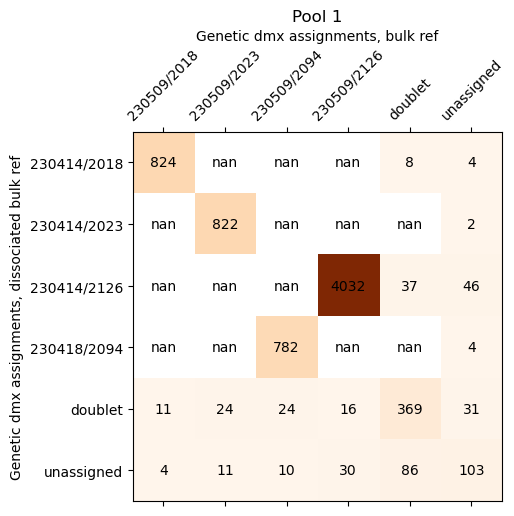

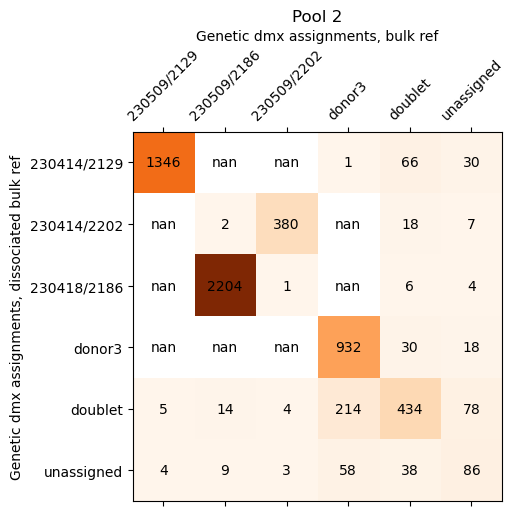

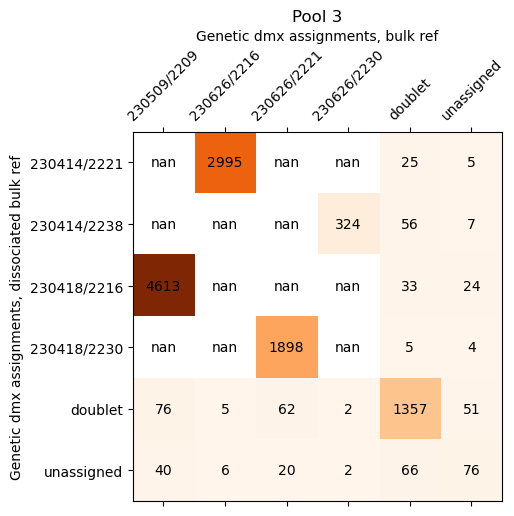

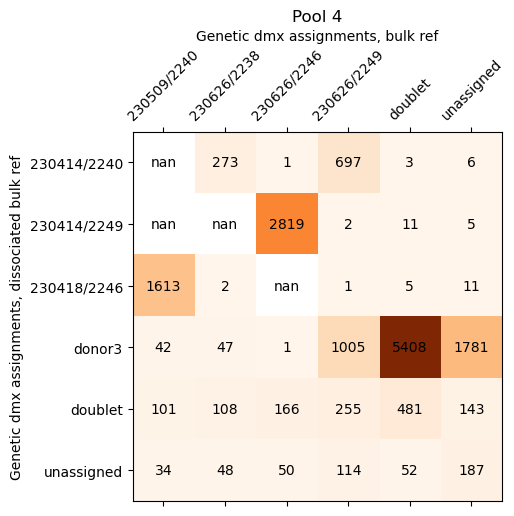

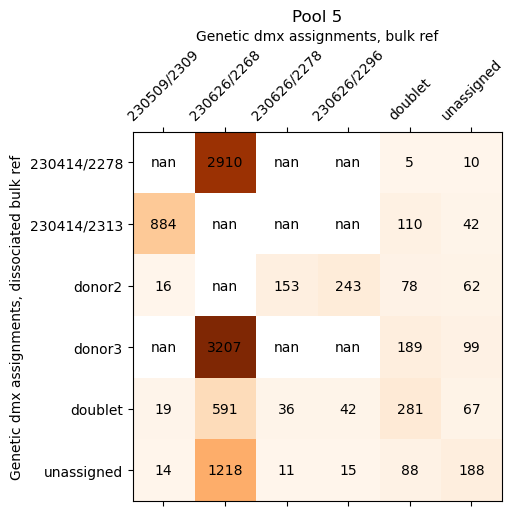

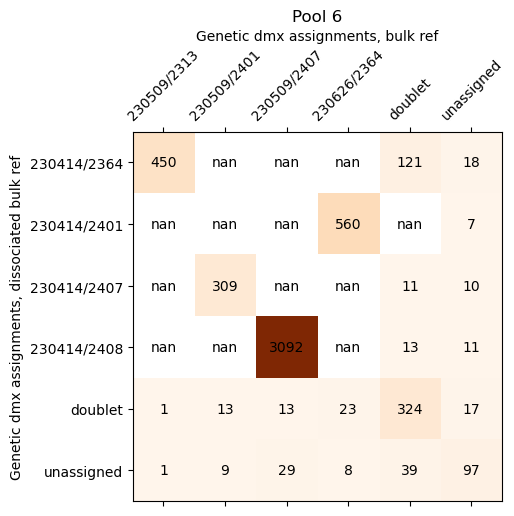

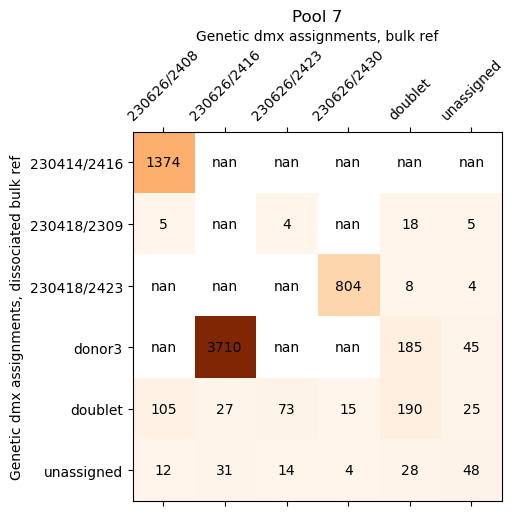

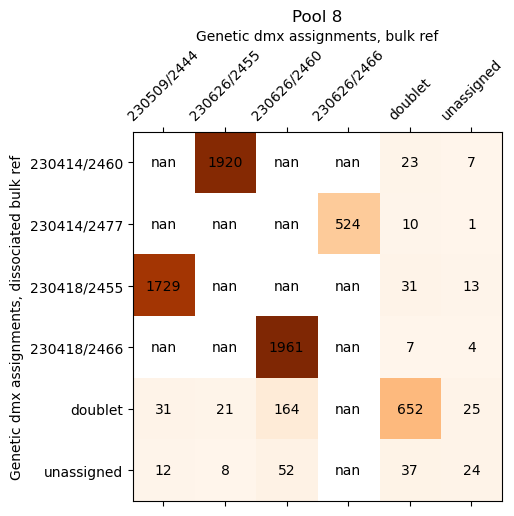

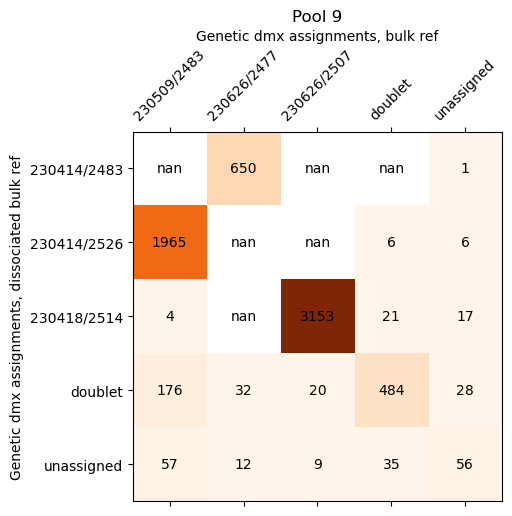

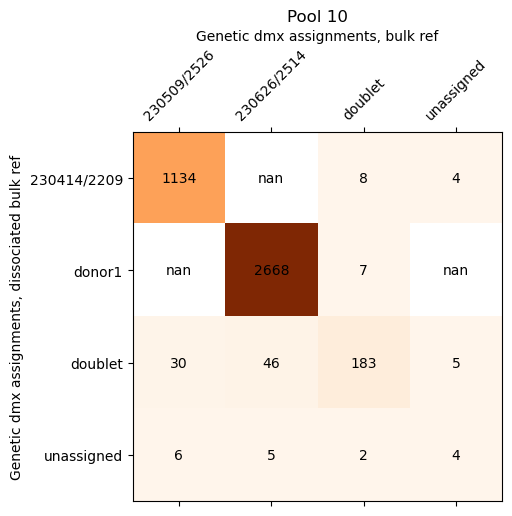

In [34]:
# Make all the plots
for i in range(1, n_pool + 1):
    viz_gex_heatmap_diss_vs_bulk(df, i, False)